# Example: composition validations

We want to be able to evaluate both an atlas and the resulting circuit on how well the recreate neuron density statistics for different cells.

parameterized validations, including the corresponding experimental data, can be imported from analysis_neuro.analyses

In [1]:
from analysis_neuro import analyses
import pandas as pd

bluebrain_models contains objects which implement measurements like cell_density, cell_count, etc.
The plan is to gradually increase the measurements available and the possible parameters of these measurements as we need them.
So for now it's only cell density, cell count, and region volume which are supported, and only for region and layer parameters, but new measurements can be added.

It will be a priority to make new methods and parameters easy to add, so that we can do it on the fly without costing too much time.

In [2]:
from bluebrain_models import BBPCircuit, BBPAtlas

In [3]:
atlas2019 = BBPAtlas("/gpfs/bbp.cscs.ch/project/proj68/entities/dev/atlas/ccf_2017-25um/20190208/", label='atlas2019')
atlas2021 = BBPAtlas("/gpfs/bbp.cscs.ch/project/proj82/entities/atlas/ThalNCX/20210531/", label='atlas2021')
atlas2022 = BBPAtlas("/gpfs/bbp.cscs.ch/project/proj148/atlas/VISp/20220512/", label='atlas2022')
VISp2022 = BBPCircuit("/gpfs/bbp.cscs.ch/project/proj148/scratch/V1/sonata/circuit_config.json", label='circuit')


{'Introduction': '\n    We evaluate the similarity of the total neuron density in the primary\n    visual cortex of the model to in-vivo values by comparing to the\n    mean density observed in @schuz_density_1989.\n    Because Schuz does not report the individual densities for the three\n    mice used, we cannot perform a statistical test.\n    So instead we use a mean squared error to quantify the mismatch.\n    We cannot render a verdict on the result, only assign a score.\n    ',
 'measurements':   layer  cell density ($cells/mm^3$) region     dataset            citation  \
 0   L23                140000.000000   VISp  Schuz 1989  schuz_density_1989   
 1    L4                200000.000000   VISp  Schuz 1989  schuz_density_1989   
 2    L5                 80000.000000   VISp  Schuz 1989  schuz_density_1989   
 3    L6                150000.000000   VISp  Schuz 1989  schuz_density_1989   
 0   L23                 90089.592350   VISp     circuit                 NaN   
 1    L4       

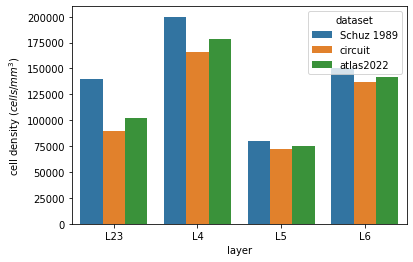

In [4]:
schuz_result = analyses.schuz_density_1989(VISp2022, atlas2022)# , atlas2019, atlas2021)
schuz_result

This validation did actually reveal a problem with the VISp circuit and the dedicated atlas, the density is too low overall, especially so in L23, even though they were constrained using this data.

I've identified the issue and am working on it for the next VISp circuit.

,species,region,whatever metadata,sample size,std cell density ($cells/mm^3$),layer
0,mouse,SSp-ll,blah blah blah,6,1910,L1
1,mouse,SSp-ll,blah blah blah,6,8136,L2
2,mouse,SSp-ll,blah blah blah,6,6822,L3
3,mouse,SSp-ll,blah blah blah,6,3778,L4
4,mouse,SSp-ll,blah blah blah,6,4138,L5
5,mouse,SSp-ll,blah blah blah,6,4060,L6


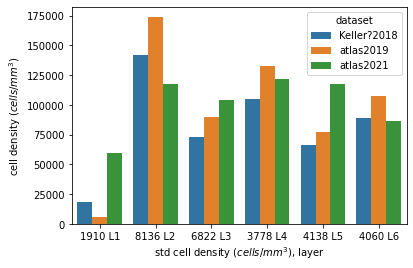

In [5]:
keller_result = analyses.keller_density_2018(atlas2019, atlas2021)
analyses.keller_density_2018.parameters

In [6]:
print(analyses.schuz_density_1989.parameters)

  layer region
0   L23   VISp
1    L4   VISp
2    L5   VISp
3    L6   VISp


In [7]:
thal2022 = BBPCircuit("/gpfs/bbp.cscs.ch/project/proj82/circuits/Thalamus/20220125/sonata/circuit_config.json", label='Thal2022')

fucking warn, lol!


/gpfs/bbp.cscs.ch/project/proj148/home/dictus/bluebrain-models/bluebrain_models/__init__.py:110: Warning: unknown parameter neuron or glia?. ignoring.
Assumption: all cells in the model satisfy the requirement neuron or glia?: neuron
  warnings.warn(


fucking warn, lol!


/gpfs/bbp.cscs.ch/project/proj148/home/dictus/bluebrain-models/bluebrain_models/__init__.py:110: Warning: unknown parameter neuron or glia?. ignoring.
Assumption: all cells in the model satisfy the requirement neuron or glia?: neuron
  warnings.warn(


fucking warn, lol!


...

fucking warn, lol!


/gpfs/bbp.cscs.ch/project/proj148/home/dictus/bluebrain-models/bluebrain_models/__init__.py:110: Warning: unknown parameter neuron or glia?. ignoring.
Assumption: all cells in the model satisfy the requirement neuron or glia?: neuron
  warnings.warn(


fucking warn, lol!


/gpfs/bbp.cscs.ch/project/proj148/home/dictus/bluebrain-models/bluebrain_models/__init__.py:110: Warning: unknown parameter neuron or glia?. ignoring.
Assumption: all cells in the model satisfy the requirement neuron or glia?: neuron
  warnings.warn(


{'Introduction': '\n    We compare the total cell counts in the thalamus model(s) to various data\n    collected from the literature and in internal projects\n    ',
 'measurements':   region     cell count neuron or glia?                        citation  \
 0     RT   68749.570000          neuron          bertschy_internal_2021   
 1    VPM   70919.190000          neuron          bertschy_internal_2021   
 2    VPL   57466.910000          neuron          bertschy_internal_2021   
 3    LGd   84434.000000          neuron  evangelio_thalamocortical_2018   
 4     LP   87476.000000          neuron  evangelio_thalamocortical_2018   
 0     RT       0.000000          neuron                             NaN   
 1    VPM  116581.038411          neuron                             NaN   
 2    VPL    4131.627029          neuron                             NaN   
 3    LGd   46452.125180          neuron                             NaN   
 4     LP   51910.562114          neuron                  

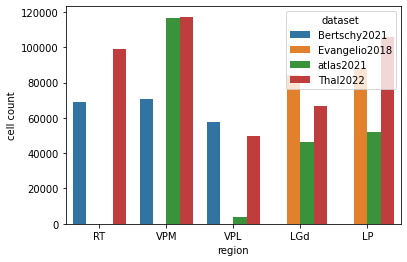

In [8]:
analyses.thalamic_nuclei_cell_counts(atlas2021, thal2022)

So the above plot is a bit wonky - it's reserving values for both datasets even when they don't provide a value.
Maybe it should be standard practice to split into two validations - as different datasets will have subtly different methods that may need to be handled differently.